In [53]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import tensorflow as tf
from random import randint
from tensorflow.keras.optimizers import Adam
from keras.models import *
from keras.layers import *
from tensorflow.keras.utils import plot_model
from matplotlib import pyplot as plt
import keras.backend as K
from keras.callbacks import ModelCheckpoint
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [54]:
SIZE_X = 256
SIZE_Y = 256
images_path ='Brain Tumor Segmentation/images'
masks_path ='Brain Tumor Segmentation/masks'
NUM_SAMPLES = 700  # Specify the number of samples to extract
start_index = 0
end_index = 500

images = []
masks = []


print(images_path)
for index, image in enumerate(tqdm(os.listdir(images_path))):
    if index >= start_index and index <= end_index:
        image_path = os.path.join(images_path, image)
        img = cv2.imread(image_path)
        img = cv2.resize(img, (256, 256)) /255.0
        images.append(img)

images = np.array(images)

print(masks_path)
for index, mask in enumerate(tqdm(os.listdir(masks_path))):
    if index >= start_index and index <= end_index:
    
        mask_path = os.path.join(masks_path, mask)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (SIZE_Y, SIZE_X), interpolation=cv2.INTER_NEAREST) / 255
        mask = mask.astype(np.uint8)
        masks.append(mask)
                 
masks = np.array(masks)

Brain Tumor Segmentation/images


100%|████████████████████████████████████████████████████████████████████████████| 3064/3064 [00:02<00:00, 1471.30it/s]


Brain Tumor Segmentation/masks


100%|████████████████████████████████████████████████████████████████████████████| 3064/3064 [00:00<00:00, 3196.84it/s]


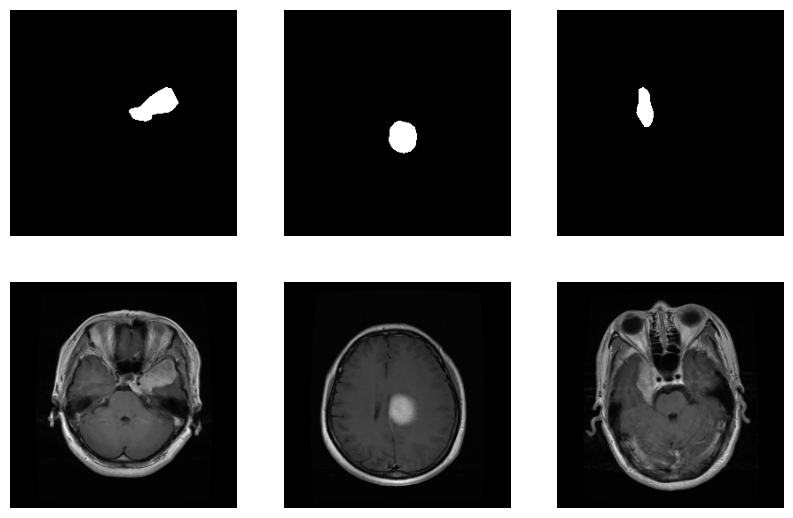

In [55]:
n_samples = 3
plt.figure(figsize = (10, 10))
for i in range(n_samples):
    plt.subplot(n_samples, n_samples, 1 + i)
    plt.axis('off')
    plt.imshow(masks[i], cmap = 'gray')
# plot target image
for i in range(n_samples):
    plt.subplot(n_samples, n_samples, 1 + n_samples + i)
    plt.axis('off')
    plt.imshow(images[i], cmap = 'gray')
plt.show()

In [56]:
masks= np.expand_dims(masks, axis = 3)
print(masks.shape)

(501, 256, 256, 1)


In [57]:
X_train, X_test, y_train, y_test = train_test_split(images, masks, 
                                                    test_size = 0.15, shuffle = True, random_state = 42)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, 
                                                  test_size = 0.2, random_state = 42) 

n_classes = 2
train_masks_cat = to_categorical(y_train, num_classes = n_classes)
test_masks_cat = to_categorical(y_test, num_classes = n_classes)
val_masks_cat = to_categorical(y_val, num_classes = n_classes)

print(f'TRAIN SET:\n'
     f'X_train shape: {X_train.shape}\n'
     f'y_train shape: {train_masks_cat.shape}\n\n'
     f'VALIDATION SET:\n'
     f'X_val shape: {X_val.shape}\n'
     f'y_val shape: {val_masks_cat.shape}\n\n'
     f'TEST SET:\n'
     f'X_test shape: {X_test.shape}\n'
     f'y_test shape: {test_masks_cat.shape}')

TRAIN SET:
X_train shape: (340, 256, 256, 3)
y_train shape: (340, 256, 256, 2)

VALIDATION SET:
X_val shape: (85, 256, 256, 3)
y_val shape: (85, 256, 256, 2)

TEST SET:
X_test shape: (76, 256, 256, 3)
y_test shape: (76, 256, 256, 2)


In [58]:
class_num = 2
img_size = (256, 256, 3) 

def double_conv_block(x, n_filters):
    x = Conv2D(n_filters, 3, padding = "same", activation = "relu", kernel_initializer = "he_normal")(x)
    x = Conv2D(n_filters, 3, padding = "same", activation = "relu", kernel_initializer = "he_normal")(x)
    return x

def downsample_block(x, n_filters):
    f = double_conv_block(x, n_filters)
    p = MaxPool2D(2)(f)
    return f, p

def upsample_block(x, conv_features, n_filters):
    x = Conv2DTranspose(n_filters, 3, 2, padding = "same")(x)
    x = concatenate([x, conv_features])
    x = double_conv_block(x, n_filters)
    return x

def build_unet_model(img_size, num_classes, activation = 'sigmoid'):
    inputs = Input(shape = img_size)
    f1, p1 = downsample_block(inputs, 64)
    f2, p2 = downsample_block(p1, 128)
    f3, p3 = downsample_block(p2, 256)
    f4, p4 = downsample_block(p3, 512)
    bottleneck = double_conv_block(p4, 1024)
    u6 = upsample_block(bottleneck, f4, 512)
    u7 = upsample_block(u6, f3, 256)
    u8 = upsample_block(u7, f2, 128)
    u9 = upsample_block(u8, f1, 64)
    outputs = Conv2D(num_classes, 1, padding = "same", activation = activation)(u9)
    unet_model = tf.keras.Model(inputs, outputs, name = "U-Net")
    return unet_model

In [59]:
LR = 0.0001 
optimizer = Adam(LR) 
loss = 'binary_crossentropy' 

import tensorflow as tf

def dice_coef(y_true, y_pred, smooth=1.0):
    class_num = y_true.shape[-1]
    for i in range(class_num):
        y_true_f = tf.keras.backend.flatten(y_true[:,:,:,i])
        y_pred_f = tf.keras.backend.flatten(y_pred[:,:,:,i])
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        loss = ((2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth))
        if i == 0:
            total_loss = loss
        else:
            total_loss = total_loss + loss
    total_loss = total_loss / class_num
    return total_loss


metrics = [dice_coef, tf.keras.metrics.MeanIoU(num_classes = n_classes)]

In [60]:
K.clear_session()

unet_model = build_unet_model(img_size, class_num, activation = 'sigmoid' )

unet_model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 256, 256, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 256, 256, 64)      │           1,792 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 256, 256, 64)      │          36,928 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 128, 128, 64)      │               0 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 128, 128, 128)     │          73,856 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 128, 128, 128)     │         147,584 │ conv2d_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 64, 64, 128)       │               0 │ conv2d_3[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 64, 64, 256)       │         295,168 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 64, 64, 256)       │         590,080 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 32, 32, 256)       │               0 │ conv2d_5[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 32, 32, 512)       │       1,180,160 │ max_pooling2d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 32, 32, 512)       │       2,359,808 │ conv2d_6[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_3               │ (None, 16, 16, 512)       │               0 │ conv2d_7[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_8 (Conv2D)             │ (None, 16, 16, 1024)      │       4,719,616 │ max_pooling2d_3[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_9 (Conv2D)             │ (None, 16, 16, 1024)      │       9,438,208 │ conv2d_8[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose              │ (None, 32, 32, 512)       │       4,719,10

 Total params: 34,513,410 (131.66 MB)

 Trainable params: 34,513,410 (131.66 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
unet_model.load_weights('unet weights.hdf5')

In [62]:
unet_model.compile(optimizer = optimizer,
                  loss = loss,
                  metrics = metrics)

In [63]:
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
checkpointer = ModelCheckpoint(filepath = 'checkpoint7.weights.h5',
                               verbose = 1,
                               save_best_only = True, save_weights_only = True)

early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001, verbose=1)

history = unet_model.fit(X_train, train_masks_cat, batch_size = 32, epochs = 10, verbose = 1,
                         shuffle = True, callbacks = [checkpointer,early_stopping,reduce_lr],
                        validation_data = (X_val, val_masks_cat))

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26s/step - dice_coef: 0.5231 - loss: 0.1081 - mean_io_u: 0.3745 
Epoch 1: val_loss improved from inf to 0.01633, saving model to checkpoint7.weights.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 314s 27s/step - dice_coef: 0.5278 - loss: 0.1038 - mean_io_u: 0.3775 - val_dice_coef: 0.6842 - val_loss: 0.0163 - val_mean_io_u: 0.4326 - learning_rate: 1.0000e-04
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27s/step - dice_coef: 0.7011 - loss: 0.0173 - mean_io_u: 0.4807 
Epoch 2: val_loss improved from 0.01633 to 0.01255, saving model to checkpoint7.weights.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 310s 28s/step - dice_coef: 0.7027 - loss: 0.0171 - mean_io_u: 0.4835 - val_dice_coef: 0.7445 - val_loss: 0.0126 - val_mean_io_u: 0.5674 - learning_rate: 1.0000e-04
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26s/step - dice_coef: 0.7746 - loss: 0.0116 - mean_io_u: 0.6033 
Epoch 3: val_loss improved from 0.01255 to 0.00999, saving model to checkpoint7.weights.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 300s

In [64]:
unet_model.load_weights('checkpoint7.weights.h5')

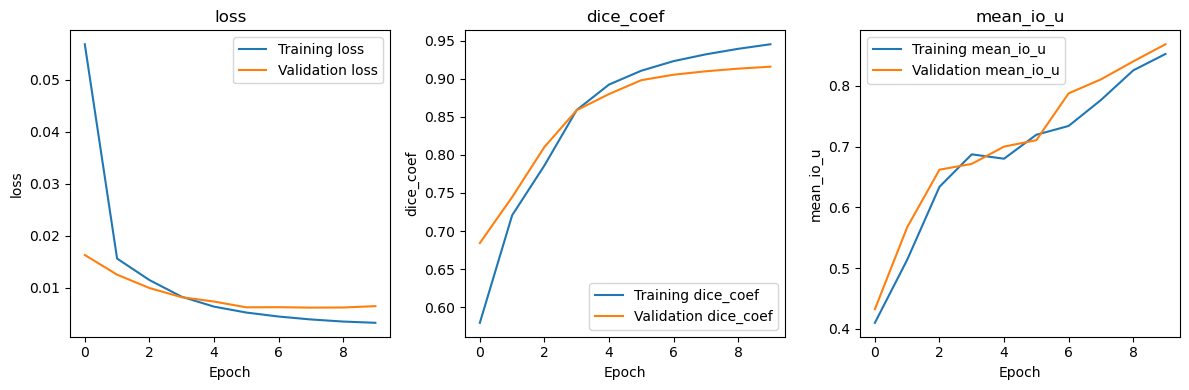

In [65]:
plt.figure(figsize=(12, 4))
plots = ['loss', 'dice_coef', 'mean_io_u']

for index, plot in enumerate(plots):
    plt.subplot(1, 3, index + 1)
    plt.plot(history.history[plot], label='Training '+ plot)
    plt.plot(history.history['val_' + plot], label='Validation '+ plot)
    plt.title(plot)
    plt.xlabel('Epoch')
    plt.ylabel(plot)
    plt.legend()
    
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


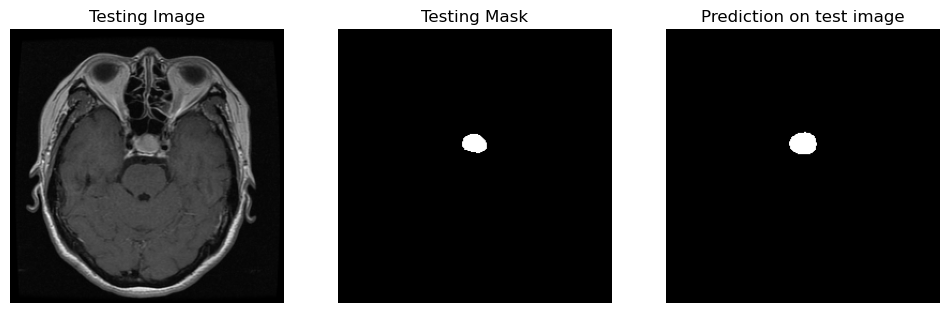

In [66]:
test_img_number = randint(0, len(X_test) - 1)
test_img = X_test[test_img_number]
test_mask = y_test[test_img_number]
test_img_input = np.expand_dims(test_img, 0)
test_pred1 = unet_model.predict(test_img_input)
test_prediction1 = np.argmax(test_pred1, axis=3)[0,:,:]

fig, (ax1, ax2, ax3) = plt.subplots(figsize = (12, 8), ncols = 3)
ax1.set_title('Testing Image')
ax1.axis('off')
ax1.imshow(test_img[:, :, 0], cmap = 'gray')
ax2.set_title('Testing Mask')
ax2.axis('off')
ax2.imshow(test_mask[:, :, 0], cmap = 'gray')
ax3.set_title('Prediction on test image')
ax3.axis('off')
pred = ax3.imshow(test_prediction1, cmap = 'gray')
plt.show()

# --------------------------- Optional -----------------------------

In [67]:
d1 = {}
d2 = {}

# Iterate through the layers of unet_model and store the trainable status of each layer in d1 dictionary
for layer in unet_model.layers:
    name = layer.name
    lis = name.split('_')
    name = lis[0]
    d1[name] = layer.trainable

print(d1)

# Iterate through the layers of unet_model and modify the trainable status based on layer names
# Set trainable=True for layers with name starting with 'conv2d', and False for other layers
for layer in unet_model.layers:
    name = layer.name
    lis = name.split('_')
    name = lis[0]
    if name == 'conv2d':
        layer.trainable = True
    else:
        layer.trainable = False
    d2[name] = layer.trainable

print('\n', d2)

{'input': True, 'conv2d': True, 'max': True, 'concatenate': True}

 {'input': False, 'conv2d': True, 'max': False, 'concatenate': False}


In [68]:
weights = []

# Iterate through the layers of unet_model and retrieve the weights of each layer
for layer in unet_model.layers:
    w = layer.get_weights()
    weights.append(w)

img_size = (256, 256, 3)
class_num = 2

# Build unet_model2 with the specified image size, number of classes, and activation function
unet_model2 = build_unet_model(img_size, class_num, activation='sigmoid')

# Iterate through the layers of unet_model2 and set the weights using the corresponding weights from unet_model
for index, layer in enumerate(unet_model2.layers):
    layer.set_weights(weights[index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


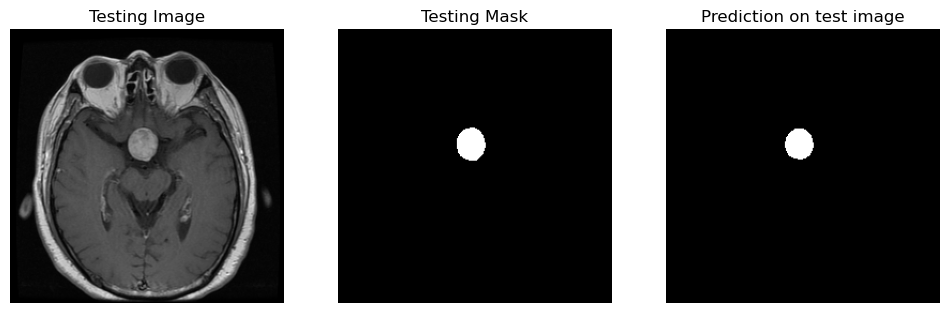

In [69]:
test_img_number = randint(0, len(X_test) - 1)
test_img = X_test[test_img_number]
test_mask = y_test[test_img_number]
test_img_input = np.expand_dims(test_img, 0)
test_pred1 = unet_model2.predict(test_img_input)    #predict using unet_model2
test_prediction1 = np.argmax(test_pred1, axis=3)[0,:,:]

fig, (ax1, ax2, ax3) = plt.subplots(figsize = (12, 8), ncols = 3)
ax1.set_title('Testing Image')
ax1.axis('off')
ax1.imshow(test_img[:, :, 0], cmap = 'gray')
ax2.set_title('Testing Mask')
ax2.axis('off')
ax2.imshow(test_mask[:, :, 0], cmap = 'gray')
ax3.set_title('Prediction on test image')
ax3.axis('off')
pred = ax3.imshow(test_prediction1, cmap = 'gray')
plt.show()

In [ ]:
unet_model.save('unet_model2.keras')